## Serialize a Spatial Reference Data using SchemaOrg and the CUAHSI.org-SRS extension

The purpose of this notebook is to evaluate how SRS data can be extracted and mapped to our Pydantic classes.

In [1]:
import os
import sys
import fiona
import hashlib
import geopandas
import mimetypes
from glob import glob
from pyproj import CRS
from pathlib import Path

# add the parent directory to the path. This is the 
# directory that contains our pydantic classes.
sys.path.append('..')
import base
import core
import dataset

Test Geographic Coordinate System representation

WGS 1984: https://spatialreference.org/ref/epsg/4326/

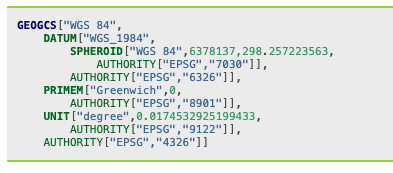

In [4]:
crs = CRS.from_epsg(4326)

srs = base.SpatialReference(
    name=crs.name,
    srsType=crs.type_name.split(' ')[0],
    code=crs.to_string(),
    wktString=crs.to_wkt(),
    projString=crs.to_proj4()
)
print(srs.model_dump_json(exclude_none=True, indent=4))

{
    "type": "SpatialReference",
    "name": "WGS 84",
    "srsType": "geographic",
    "code": "EPSG:4326",
    "wktString": "GEOGCRS[\"WGS 84\",ENSEMBLE[\"World Geodetic System 1984 ensemble\",MEMBER[\"World Geodetic System 1984 (Transit)\"],MEMBER[\"World Geodetic System 1984 (G730)\"],MEMBER[\"World Geodetic System 1984 (G873)\"],MEMBER[\"World Geodetic System 1984 (G1150)\"],MEMBER[\"World Geodetic System 1984 (G1674)\"],MEMBER[\"World Geodetic System 1984 (G1762)\"],MEMBER[\"World Geodetic System 1984 (G2139)\"],MEMBER[\"World Geodetic System 1984 (G2296)\"],ELLIPSOID[\"WGS 84\",6378137,298.257223563,LENGTHUNIT[\"metre\",1]],ENSEMBLEACCURACY[2.0]],PRIMEM[\"Greenwich\",0,ANGLEUNIT[\"degree\",0.0174532925199433]],CS[ellipsoidal,2],AXIS[\"geodetic latitude (Lat)\",north,ORDER[1],ANGLEUNIT[\"degree\",0.0174532925199433]],AXIS[\"geodetic longitude (Lon)\",east,ORDER[2],ANGLEUNIT[\"degree\",0.0174532925199433]],USAGE[SCOPE[\"Horizontal component of 3D system.\"],AREA[\"World.\"],BBOX[

Test Projected Coordinate System represenation


WGS 84 / EPSG Arctic Regional zone B2: https://spatialreference.org/ref/epsg/5927/wkt.html

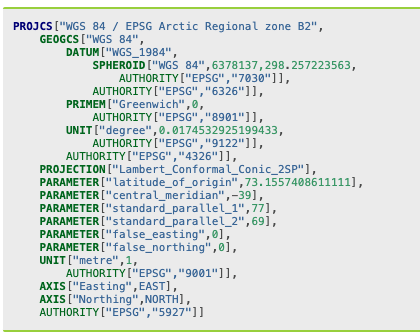

In [5]:
crs = CRS.from_epsg(5927)

srs = base.SpatialReference(
    name=crs.name,
    srsType=crs.type_name.split(' ')[0],
    code=crs.to_string(),
    wktString=crs.to_wkt(),
    projString=crs.to_proj4()
)
print(srs.model_dump_json(exclude_none=True, indent=4))

{
    "type": "SpatialReference",
    "name": "WGS 84 / EPSG Arctic Regional zone B2",
    "srsType": "projected",
    "code": "EPSG:5927",
    "wktString": "PROJCRS[\"WGS 84 / EPSG Arctic Regional zone B2\",BASEGEOGCRS[\"WGS 84\",ENSEMBLE[\"World Geodetic System 1984 ensemble\",MEMBER[\"World Geodetic System 1984 (Transit)\"],MEMBER[\"World Geodetic System 1984 (G730)\"],MEMBER[\"World Geodetic System 1984 (G873)\"],MEMBER[\"World Geodetic System 1984 (G1150)\"],MEMBER[\"World Geodetic System 1984 (G1674)\"],MEMBER[\"World Geodetic System 1984 (G1762)\"],MEMBER[\"World Geodetic System 1984 (G2139)\"],MEMBER[\"World Geodetic System 1984 (G2296)\"],ELLIPSOID[\"WGS 84\",6378137,298.257223563,LENGTHUNIT[\"metre\",1]],ENSEMBLEACCURACY[2.0]],PRIMEM[\"Greenwich\",0,ANGLEUNIT[\"degree\",0.0174532925199433]],ID[\"EPSG\",4326]],CONVERSION[\"EPSG Arctic Regional LCC zone B2\",METHOD[\"Lambert Conic Conformal (2SP)\",ID[\"EPSG\",9802]],PARAMETER[\"Latitude of false origin\",73.1557408611111,ANGLE